# HW1 — Analytical Performance Model of a Small CNN

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import csv, json, os, time, subprocess

## 1. Model

In [2]:
import torch.nn as nn

class SmallCNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=1, stride=1, padding=0, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 512, kernel_size=1, stride=1, padding=0, bias=False),
            nn.ReLU(inplace=True),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.head(self.features(x))

model = SmallCNN()

## 2. Equations

In [3]:
NUM_PARAMS = 1_040_324
A_FLOP = 17716.0
B_FLOP = 313344.0
PEAK_ACT = 11.0
C_ELEM = 49.0
D_ELEM = 1636.0
E_ELEM = 1_040_324.0
BPW = 4

def flops(S, B):
    S, B = np.asarray(S, dtype=np.float64), np.asarray(B, dtype=np.float64)
    return B * (A_FLOP * S**2 + B_FLOP)

def memory(S, B):
    S, B = np.asarray(S, dtype=np.float64), np.asarray(B, dtype=np.float64)
    return BPW * (NUM_PARAMS + PEAK_ACT * B * S**2)

def bytes_moved(S, B):
    S, B = np.asarray(S, dtype=np.float64), np.asarray(B, dtype=np.float64)
    return BPW * (C_ELEM * B * S**2 + D_ELEM * B + E_ELEM)

def latency(S, B, theta):
    return theta[0] + theta[1] * flops(S, B) + theta[2] * bytes_moved(S, B)

def energy(S, B, theta_e):
    return theta_e[0] + theta_e[1] * flops(S, B) + theta_e[2] * bytes_moved(S, B)

## 3. Grid

In [4]:
BASE_S = [32, 64, 128, 224, 256, 384, 512]
BASE_B = [1, 2, 4, 8, 16, 32, 64, 128, 256]

rng = np.random.RandomState(42)

all_mult = [s for s in range(32, 513, 16) if s not in BASE_S]
VAL_S = sorted(rng.choice(all_mult, size=4, replace=False).tolist())

non_pow2 = [b for b in range(1, 257) if b not in BASE_B and (b & (b-1)) != 0]
VAL_B = sorted(rng.choice(non_pow2, size=3, replace=False).tolist())

configs = []
seen = set()
for s_list, is_v in [(BASE_S, False), (VAL_S, True)]:
    for b_list, is_v2 in [(BASE_B, False), (VAL_B, True)]:
        for s in s_list:
            for b in b_list:
                key = (s, b)
                if key not in seen:
                    seen.add(key)
                    configs.append((s, b, is_v or is_v2))

## 4. Measure

In [5]:
WARMUP = 5
N_MEASURE = 20

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cuda.matmul.allow_tf32 = False

model = model.to(device).eval()

def gpu_power_w():
    try:
        out = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=power.draw', '--format=csv,noheader,nounits'],
            timeout=2).decode().strip()
        return float(out.split('\n')[0])
    except Exception:
        return None

rows = []
for i, (S, B, is_val) in enumerate(configs):
    try:
        x = torch.randn(B, 3, S, S, device=device, dtype=torch.float32)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        rows.append((S, B, np.nan, np.nan, np.nan, True, is_val))
        print(f'S={S:4d} B={B:4d} OOM')
        continue

    try:
        for _ in range(WARMUP):
            with torch.inference_mode(): _ = model(x)
            torch.cuda.synchronize()
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        rows.append((S, B, np.nan, np.nan, np.nan, True, is_val))
        print(f'S={S:4d} B={B:4d} OOM')
        continue

    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    lats, pws = [], []
    try:
        for _ in range(N_MEASURE):
            pw = gpu_power_w()
            if pw is not None: pws.append(pw)
            t0 = time.perf_counter()
            with torch.inference_mode(): _ = model(x)
            torch.cuda.synchronize()
            lats.append(time.perf_counter() - t0)
    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()
        rows.append((S, B, np.nan, np.nan, np.nan, True, is_val))
        print(f'S={S:4d} B={B:4d} OOM')
        continue

    peak_mem = torch.cuda.max_memory_allocated()
    med_lat = float(np.median(lats))
    avg_pw = float(np.mean(pws)) if pws else None
    en = avg_pw * med_lat if avg_pw else None
    rows.append((S, B, med_lat, peak_mem, en, False, is_val))
    print(f'S={S:4d} B={B:4d} lat={med_lat*1e3:.3f}ms mem={peak_mem/1e6:.1f}MB')

S_all = np.array([r[0] for r in rows])
B_all = np.array([r[1] for r in rows])
lat_all = np.array([r[2] for r in rows])
mem_all = np.array([r[3] for r in rows])
en_all = np.array([r[4] for r in rows])
oom_all = np.array([r[5] for r in rows])
val_all = np.array([r[6] for r in rows])

S=  32 B=   1 lat=0.969ms mem=18.8MB
S=  32 B=   2 lat=1.423ms mem=18.9MB
S=  32 B=   4 lat=1.632ms mem=19.1MB
S=  32 B=   8 lat=0.894ms mem=19.5MB
S=  32 B=  16 lat=1.033ms mem=14.8MB
S=  32 B=  32 lat=1.441ms mem=16.0MB
S=  32 B=  64 lat=1.871ms mem=18.2MB
S=  32 B= 128 lat=3.950ms mem=59.3MB
S=  32 B= 256 lat=6.881ms mem=103.7MB
S=  64 B=   1 lat=0.920ms mem=24.0MB
S=  64 B=   2 lat=1.080ms mem=24.1MB
S=  64 B=   4 lat=1.064ms mem=24.9MB
S=  64 B=   8 lat=1.173ms mem=17.8MB
S=  64 B=  16 lat=1.312ms mem=19.5MB
S=  64 B=  32 lat=2.018ms mem=22.6MB
S=  64 B=  64 lat=2.915ms mem=31.6MB
S=  64 B= 128 lat=7.510ms mem=76.2MB
S=  64 B= 256 lat=10.671ms mem=138.3MB
S= 128 B=   1 lat=1.136ms mem=24.4MB
S= 128 B=   2 lat=1.073ms mem=17.8MB
S= 128 B=   4 lat=1.449ms mem=19.5MB
S= 128 B=   8 lat=2.224ms mem=22.6MB
S= 128 B=  16 lat=2.912ms mem=31.6MB
S= 128 B=  32 lat=5.144ms mem=49.4MB
S= 128 B=  64 lat=8.966ms mem=119.3MB
S= 128 B= 128 lat=16.953ms mem=223.5MB
S= 128 B= 256 lat=27.844ms mem=4

## 5. Save CSV

In [6]:
os.makedirs('results', exist_ok=True)

with open('results/measurements.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['S', 'B', 'latency_s', 'memory_bytes', 'energy_j', 'is_oom', 'is_validation'])
    for r in rows:
        S, B, lat, mem, en, oom, v = r
        w.writerow([
            S, B,
            f'{lat:.9f}' if not np.isnan(lat) else '',
            f'{mem}' if not np.isnan(mem) else '',
            f'{en:.6f}' if en is not None and not np.isnan(en) else '',
            int(oom), int(v),
        ])

## 6. Calibrate

In [7]:
ok = ~oom_all
train = ok & ~val_all
val_mask = ok & val_all

f_train = flops(S_all[train], B_all[train])
b_train = bytes_moved(S_all[train], B_all[train])
X_train = np.column_stack([np.ones_like(f_train), f_train, b_train])

theta, _, _, _ = np.linalg.lstsq(X_train, lat_all[train], rcond=None)
lat_pred_train = X_train @ theta
ss_res = np.sum((lat_all[train] - lat_pred_train)**2)
ss_tot = np.sum((lat_all[train] - np.mean(lat_all[train]))**2)
r2_lat = 1 - ss_res / ss_tot

if val_mask.any():
    f_v = flops(S_all[val_mask], B_all[val_mask])
    b_v = bytes_moved(S_all[val_mask], B_all[val_mask])
    X_v = np.column_stack([np.ones_like(f_v), f_v, b_v])
    mape = np.mean(np.abs((lat_all[val_mask] - X_v @ theta) / lat_all[val_mask])) * 100

has_en = ok & ~np.isnan(en_all)
train_e = has_en & ~val_all
theta_e = np.array([0, 0, 0], dtype=np.float64)
r2_en = None
if train_e.sum() >= 3:
    f_e = flops(S_all[train_e], B_all[train_e])
    b_e = bytes_moved(S_all[train_e], B_all[train_e])
    X_e = np.column_stack([np.ones_like(f_e), f_e, b_e])
    theta_e, _, _, _ = np.linalg.lstsq(X_e, en_all[train_e], rcond=None)
    en_pred = X_e @ theta_e
    ss_res_e = np.sum((en_all[train_e] - en_pred)**2)
    ss_tot_e = np.sum((en_all[train_e] - np.mean(en_all[train_e]))**2)
    r2_en = 1 - ss_res_e / ss_tot_e

theta_data = {'theta': theta.tolist(), 'r2_latency': float(r2_lat)}
if r2_en is not None:
    theta_data['theta_energy'] = theta_e.tolist()
    theta_data['r2_energy'] = float(r2_en)
with open('results/theta.json', 'w') as f:
    json.dump(theta_data, f, indent=2)

## 7. Plots

In [8]:
os.makedirs('results/figures', exist_ok=True)

def pred_vs_meas(measured, predicted, title, unit, train_m, val_m):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(measured[train_m], predicted[train_m], c='C0', alpha=0.6, s=20, label='Train')
    if val_m.any():
        ax.scatter(measured[val_m], predicted[val_m], c='C1', alpha=0.8, s=30, marker='D', label='Validation')
    lo = min(measured[train_m].min(), predicted[train_m].min())
    hi = max(measured[train_m].max(), predicted[train_m].max())
    m = (hi - lo) * 0.05
    ax.plot([lo-m, hi+m], [lo-m, hi+m], 'k--', alpha=0.4, lw=1)
    ax.set_xlabel(f'Measured ({unit})')
    ax.set_ylabel(f'Predicted ({unit})')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_aspect('equal', adjustable='datalim')
    fig.tight_layout()
    return fig

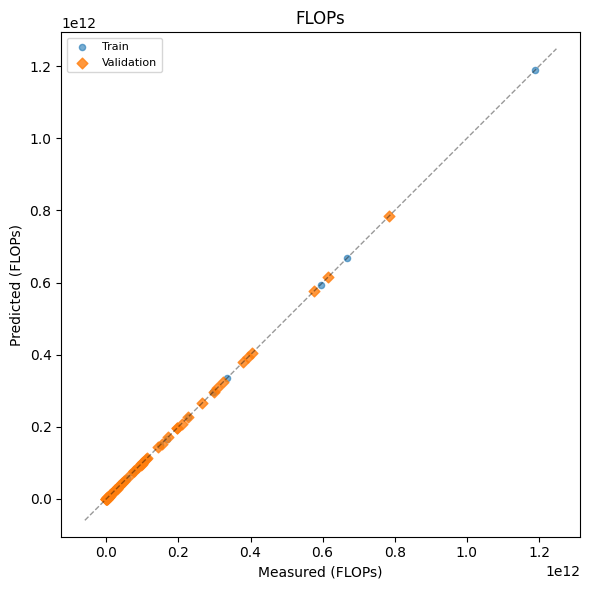

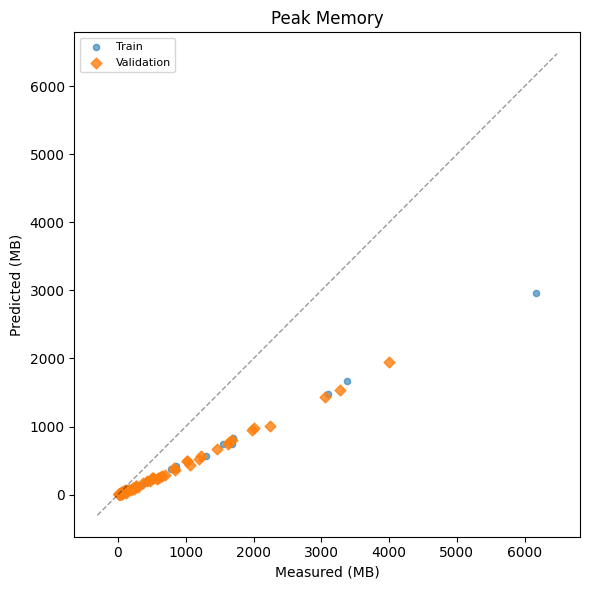

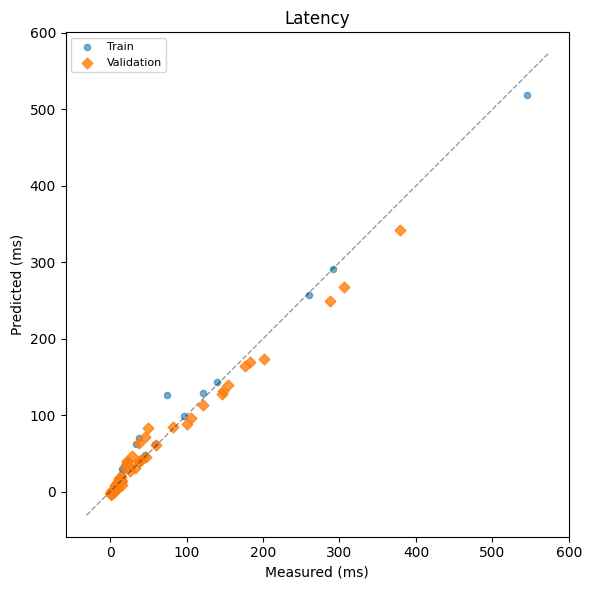

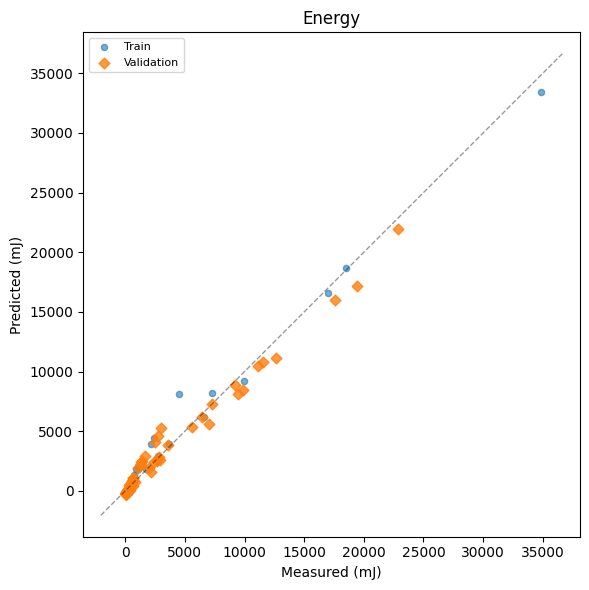

In [9]:
f_ok = flops(S_all[ok], B_all[ok])
fig = pred_vs_meas(f_ok, f_ok, 'FLOPs', 'FLOPs', train[ok], val_mask[ok])
fig.savefig('results/figures/flops.png', dpi=150)
plt.show()

m_pred = memory(S_all[ok], B_all[ok])
fig = pred_vs_meas(mem_all[ok]/1e6, m_pred/1e6, 'Peak Memory', 'MB', train[ok], val_mask[ok])
fig.savefig('results/figures/memory.png', dpi=150)
plt.show()

lat_pred = latency(S_all[ok], B_all[ok], theta)
fig = pred_vs_meas(lat_all[ok]*1e3, lat_pred*1e3, 'Latency', 'ms', train[ok], val_mask[ok])
fig.savefig('results/figures/latency.png', dpi=150)
plt.show()

has_en_mask = ok & ~np.isnan(en_all)
if has_en_mask.sum() > 3:
    en_pred = energy(S_all[has_en_mask], B_all[has_en_mask], theta_e)
    fig = pred_vs_meas(en_all[has_en_mask]*1e3, en_pred*1e3, 'Energy', 'mJ',
                       train[has_en_mask], val_mask[has_en_mask])
    fig.savefig('results/figures/energy.png', dpi=150)
    plt.show()

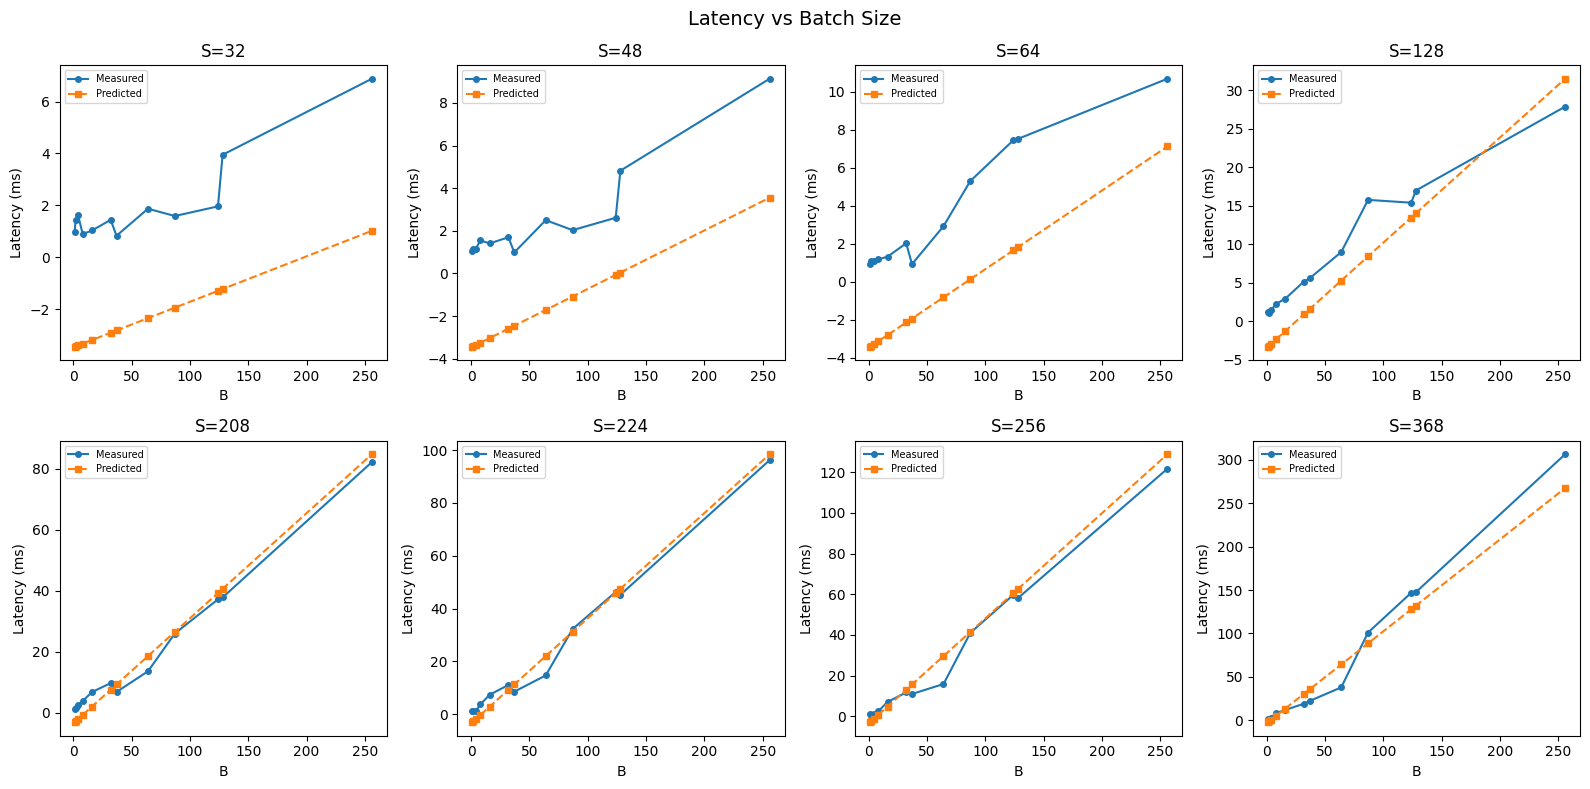

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
unique_s = sorted(set(S_all[ok]))
for idx, sv in enumerate(unique_s[:8]):
    ax = axes[idx]
    mask = ok & (S_all == sv)
    bv = B_all[mask]
    si = np.argsort(bv)
    ax.plot(bv[si], lat_all[mask][si]*1e3, 'o-', label='Measured', ms=4)
    ax.plot(bv[si], latency(sv, bv[si], theta)*1e3, 's--', label='Predicted', ms=4)
    ax.set_xlabel('B'); ax.set_ylabel('Latency (ms)'); ax.set_title(f'S={sv}')
    ax.legend(fontsize=7)
fig.suptitle('Latency vs Batch Size', fontsize=14)
fig.tight_layout()
fig.savefig('results/figures/latency_vs_batch.png', dpi=150)
plt.show()

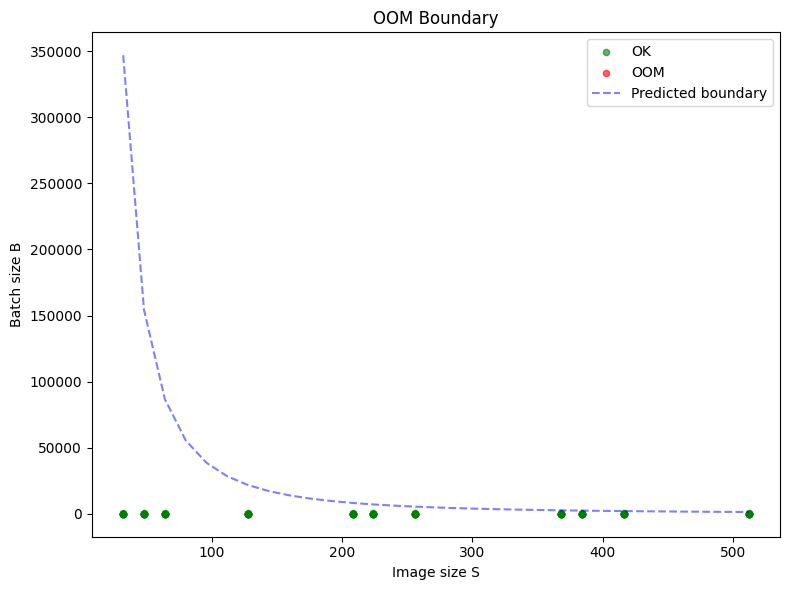

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(S_all[~oom_all], B_all[~oom_all], c='green', alpha=0.6, s=20, label='OK')
ax.scatter(S_all[oom_all], B_all[oom_all], c='red', alpha=0.6, s=20, label='OOM')

try:
    gpu_cap = torch.cuda.get_device_properties(0).total_memory
    s_range = np.arange(32, 513, 16)
    b_boundary = (gpu_cap / BPW - NUM_PARAMS) / (PEAK_ACT * s_range**2)
    ax.plot(s_range, b_boundary, 'b--', alpha=0.5, label='Predicted boundary')
except Exception:
    pass

ax.set_xlabel('Image size S'); ax.set_ylabel('Batch size B')
ax.set_title('OOM Boundary')
ax.legend()
fig.tight_layout()
fig.savefig('results/figures/oom_boundary.png', dpi=150)
plt.show()

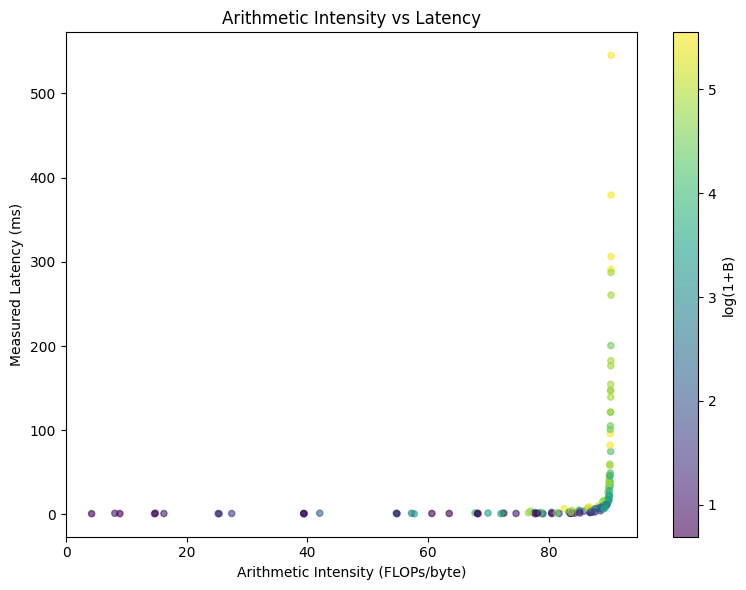

In [12]:
f_ok2 = flops(S_all[ok], B_all[ok])
b_ok2 = bytes_moved(S_all[ok], B_all[ok])
intensity = f_ok2 / b_ok2

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(intensity, lat_all[ok]*1e3, c=np.log1p(B_all[ok]), cmap='viridis', alpha=0.6, s=20)
ax.set_xlabel('Arithmetic Intensity (FLOPs/byte)')
ax.set_ylabel('Measured Latency (ms)')
ax.set_title('Arithmetic Intensity vs Latency')
plt.colorbar(sc, ax=ax, label='log(1+B)')
fig.tight_layout()
fig.savefig('results/figures/arithmetic_intensity.png', dpi=150)
plt.show()